### 线性逻辑回归决策边界

In [68]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification  # 导入用于生成模拟分类数据集的函数
from sklearn.linear_model import LogisticRegression  # 导入逻辑回归分类模型

In [69]:
X, y = make_classification( # 生成一个二分类模拟数据集
    n_samples=200,          # 生成200个样本
    n_features=2,           # 每个样本包含2个特征
    n_redundant=0,          # 不生成冗余特征
    n_classes=2,            # 分类类别数量为2
    n_clusters_per_class=1, # 每个类别包含1个数据簇
    random_state=1024)      # 固定随机种子，保证结果可重复

In [70]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=233, shuffle=True, stratify=y)

In [71]:
clf = LogisticRegression()  # 创建逻辑回归模型
clf.fit(X_train, y_train);  # 使用训练集训练模型

In [72]:
clf.score(X_train, y_train)  # 计算模型在训练集上的准确率

0.9357142857142857

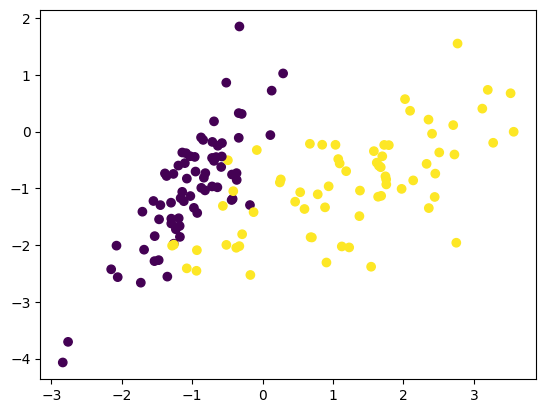

In [73]:
plt.scatter(X_train[:,0], X_train[:,1], c=y_train)
plt.show()

In [74]:
clf.coef_

array([[ 3.03386244, -1.81493954]])

In [75]:
clf.intercept_

array([-1.13231228])

In [76]:
x1 = np.linspace(-4, 4, 1000)  # 在 -4 到 4 之间生成 1000 个等间隔的数，作为决策边界的横坐标 x1

In [77]:
x2 = (-clf.coef_[0][0] * x1 - clf.intercept_) / clf.coef_[0][1]  # 根据线性模型的决策边界方程 w1*x1 + w2*x2 + b = 0，计算每个 x1 对应的纵坐标 x2

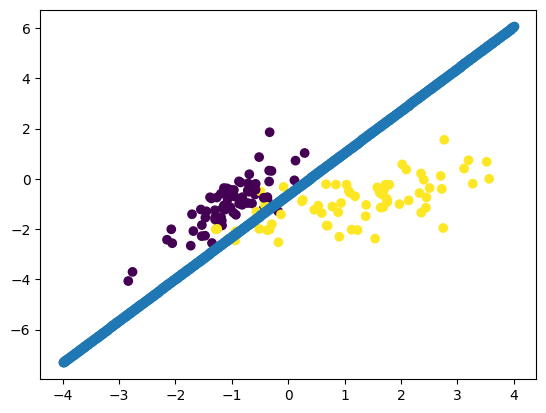

In [78]:
plt.scatter(X_train[:,0], X_train[:,1], c=y_train)
plt.scatter(x1, x2)
plt.show()

### 决策边界绘制函数

In [79]:
def decision_boundary_plot(X, y, clf):
    # 设置第一个特征 x1 的绘图范围，并在最小值和最大值两侧各扩展 1
    axis_x1_min, axis_x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    # 设置第二个特征 x2 的绘图范围，并在最小值和最大值两侧各扩展 1
    axis_x2_min, axis_x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    x1, x2 = np.meshgrid(     # 按照 0.01 的步长生成二维坐标网格
        np.arange(axis_x1_min, axis_x1_max, 0.01),
        np.arange(axis_x2_min, axis_x2_max, 0.01))
    z = clf.predict(np.c_[x1.ravel(), x2.ravel()])  # 将网格坐标展开并组合成模型需要的二维特征矩阵，然后进行分类预测
    z = z.reshape(x1.shape)  # 将一维预测结果恢复成与坐标网格相同的二维形状
    from matplotlib.colors import ListedColormap  # 导入自定义颜色映射工具
    custom_cmap = ListedColormap(["#F5B9EF", "#FFFFFF", "#F9F9CB"])  # 定义三个类别对应的背景颜色
    plt.contourf(x1, x2, z, cmap=custom_cmap)  # 绘制不同预测类别对应的决策区域
    plt.scatter(X[:, 0], X[:, 1], c=y)  # 绘制原始样本点，颜色由真实标签 y 决定

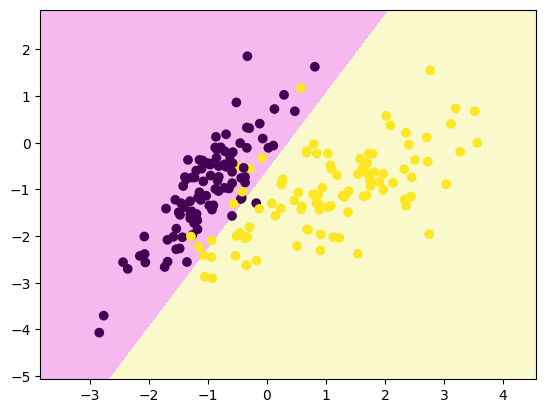

In [80]:
decision_boundary_plot(X, y, clf)

### 三分类的决策边界

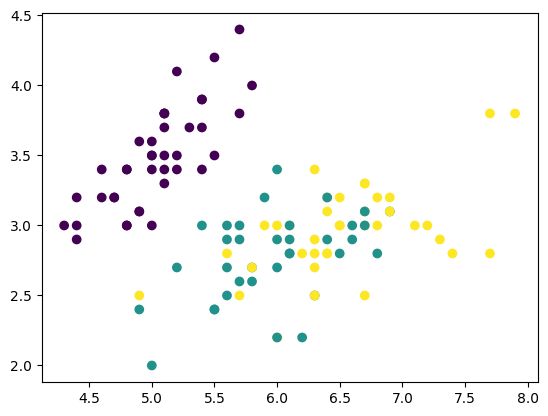

In [81]:
from sklearn import datasets
iris = datasets.load_iris()
X = iris.data[:, :2]
y = iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=666)
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train)
plt.show()

In [82]:
clf.fit(X_train, y_train);

In [83]:
clf.score(X_test, y_test)

0.7894736842105263

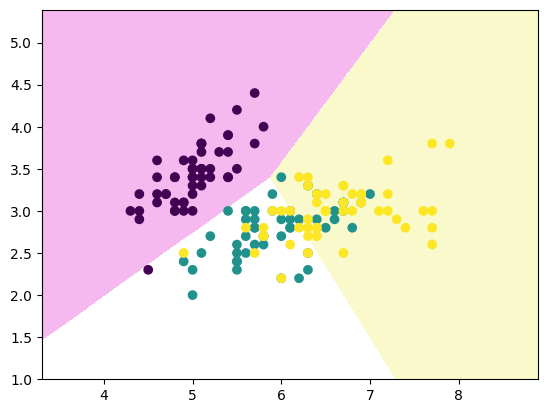

In [84]:
decision_boundary_plot(X, y, clf)

### 多项式逻辑回归的决策边界

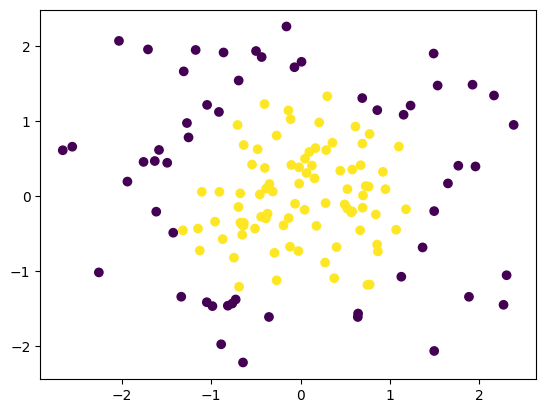

In [85]:
np.random.seed(0)
# 从均值为 0、标准差为 1 的正态分布中生成随机数据。一共生成 200 个样本，每个样本包含 2 个特征。X 的形状为 (200, 2)。
X = np.random.normal(0, 1, size=(200, 2))
# 计算每个样本两个特征的平方和：x₁² + x₂²。当平方和小于 2 时，判断结果为 True；否则为 False。再将 True/False 转换为整数 1/0，作为分类标签。
y = np.array((X[:, 0] ** 2) + (X[:, 1] ** 2) < 2, dtype="int")
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=233, shuffle=True, stratify=y)
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train)
plt.show()

In [86]:
from sklearn.pipeline import Pipeline  # 导入 Pipeline，用于按顺序组合多个数据处理步骤和模型

In [87]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler

In [88]:
clf_pipe = Pipeline([  # 创建机器学习流水线
    ("poly", PolynomialFeatures(degree=2)),  # 生成二次多项式特征，例如 x1²、x1x2、x2²
    ("std_scaler", StandardScaler()),        # 对生成后的特征进行标准化，使其均值接近 0、标准差接近 1
    ("log_reg", LogisticRegression())])      # 使用逻辑回归模型进行分类

In [89]:
clf_pipe.fit(X_train, y_train);

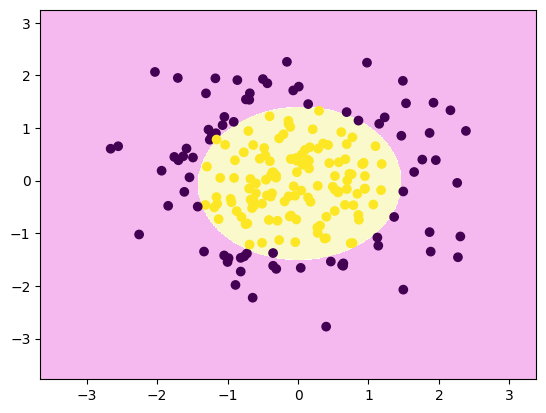

In [90]:
decision_boundary_plot(X, y, clf_pipe)